In [1]:
import json, glob, os
import numpy as np
import pandas as pd
from scipy import stats

def load_paired(pca_dir, meta_path):
    """Returns (faithful, unfaithful) as lists of DataFrames, sorted by pair id so index i matches across lists."""
    meta = json.load(open(meta_path))

    def safe(label):
        s = label.strip().lower()
        for ch in ['/', '\\', ':', ' ', ',', '|', '*', '?', '\n', '\t', '(', ')', '[', ']']:
            s = s.replace(ch, '_')
        while '__' in s: s = s.replace('__', '_')
        return s.strip('._')

    f_by_id, u_by_id = {}, {}
    for csv_file in glob.glob(pca_dir + '/*.csv'):
        label_safe = os.path.basename(csv_file).replace('_pca3d.csv', '')
        matched = next((k for k in meta if safe(k) == label_safe), None)
        if matched is None: continue
        df = pd.read_csv(csv_file)
        if len(df) < 2: continue
        pid = int(meta[matched]['topic'].split('_')[-1])
        if meta[matched]['faithful']: f_by_id[pid] = df
        else:                         u_by_id[pid] = df

    common = sorted(set(f_by_id) & set(u_by_id))
    faithful   = [f_by_id[i] for i in common]
    unfaithful = [u_by_id[i] for i in common]
    print(f'Loaded {len(common)} pairs from {pca_dir}')
    return faithful, unfaithful

faithful_21,    unfaithful_21    = load_paired(
    'results/mistake_geometry_layer21/data/pca/mistake_sqa_layer21',
    'fur_embeddings/mistake_sqa_layer21/embeddings_meta.json'
)
faithful_final, unfaithful_final = load_paired(
    'results/mistake_geometry/data/pca/mistake_sqa_llama3b',
    'fur_embeddings/mistake_sqa_llama3b/embeddings_meta.json'
)

FileNotFoundError: [Errno 2] No such file or directory: 'fur_embeddings/mistake_sqa_layer21/embeddings_meta.json'

In [4]:
# ── Geometric feature functions ───────────────────────────────────────────
def pts(df): return df[['pc1','pc2','pc3']].values

def arclength(df):
    p = pts(df); return np.sum(np.linalg.norm(np.diff(p, axis=0), axis=1))

def net_displacement(df):
    p = pts(df); return np.linalg.norm(p[-1] - p[0])

def straightness(df):
    a, n = arclength(df), net_displacement(df); return n / a if a > 1e-9 else 0.

def mean_step_size(df):
    p = pts(df); return np.linalg.norm(np.diff(p, axis=0), axis=1).mean()

def step_size_std(df):
    p = pts(df); return np.linalg.norm(np.diff(p, axis=0), axis=1).std()

def mean_curvature(df):
    p = pts(df)
    if len(p) < 3: return 0.
    d1, d2 = np.diff(p, axis=0), np.diff(np.diff(p, axis=0), axis=0)
    norms = np.linalg.norm(d1[:-1], axis=1)
    cross = np.linalg.norm(np.cross(d1[:-1], d2), axis=1)
    mask  = norms > 1e-9
    return float(np.mean(cross[mask] / (norms[mask]**2 + 1e-9))) if mask.any() else 0.

def final_pc1(df): return float(pts(df)[-1, 0])
def final_pc2(df): return float(pts(df)[-1, 1])
def final_pc3(df): return float(pts(df)[-1, 2])
def pc1_range(df): return float(pts(df)[:, 0].max() - pts(df)[:, 0].min())
def pc2_range(df): return float(pts(df)[:, 1].max() - pts(df)[:, 1].min())

METRICS = [
    ('arclength',        arclength),
    ('net_displacement', net_displacement),
    ('straightness',     straightness),
    ('mean_step_size',   mean_step_size),
    ('step_size_std',    step_size_std),
    ('mean_curvature',   mean_curvature),
    ('final_pc1',        final_pc1),
    ('final_pc2',        final_pc2),
    ('final_pc3',        final_pc3),
    ('pc1_range',        pc1_range),
    ('pc2_range',        pc2_range),
]

def compare_table(faithful, unfaithful, layer_label):
    rows = []
    for name, fn in METRICS:
        fv = np.array([fn(df) for df in faithful])
        uv = np.array([fn(df) for df in unfaithful])
        diffs = fv - uv                           # paired differences (index i matches)
        _, p  = stats.wilcoxon(diffs)
        d     = diffs.mean() / (np.concatenate([fv, uv]).std() + 1e-12)
        sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        rows.append({'Metric': name,
                     'Faithful':    round(fv.mean(), 4),
                     'Unfaithful':  round(uv.mean(), 4),
                     'Diff (F-U)':  round(diffs.mean(), 4),
                     'Cohen d':     round(d, 3),
                     'p-value':     p,
                     'Sig':         sig})
    df = pd.DataFrame(rows)
    print(f'\n--- {layer_label} ---')
    display(df.style
        .apply(lambda r: ['background-color:#fff3cd' if r['p-value'] < 0.05 else '' for _ in r], axis=1)
        .format({'p-value': '{:.2e}', 'Faithful': '{:.4f}', 'Unfaithful': '{:.4f}',
                 'Diff (F-U)': '{:.4f}', 'Cohen d': '{:.3f}'})
        .hide(axis='index'))
    return df

df_21    = compare_table(faithful_21,    unfaithful_21,    'Layer 21  (75% depth)')
df_final = compare_table(faithful_final, unfaithful_final, 'Layer 28  (final layer)')

NameError: name 'faithful_21' is not defined

## 5-MCQ (5_mcq_results.json)

Colored by faithfulness score (derived from unlearning, not mistake injection):
- `openbook_9-491` (score=0.999): **faithful**
- `openbook_508`   (score=0.256): medium
- `openbook_1955`  (score=0.049): **unfaithful**

Loaded 6 records from data/fur_anchor_embeddings.pkl
  openbook_7-976        ff_soft=0.0580  condition=sweep_3  epoch=1  anchors=9/9
  openbook_9-520        ff_soft=0.4802  condition=sweep_3  epoch=1  anchors=9/9
  openbook_508          ff_soft=0.7578  condition=sweep_1  epoch=1  anchors=9/9
  openbook_9-655        ff_soft=0.9153  condition=sweep_3  epoch=2  anchors=9/9
  openbook_1955         ff_soft=0.9692  condition=sweep_2  epoch=2  anchors=9/9
  openbook_9-491        ff_soft=0.9953  condition=sweep_1  epoch=1  anchors=9/9

Shared PCA explained variance:  PC1=0.145  PC2=0.133  PC3=0.108  (cumulative=0.385)


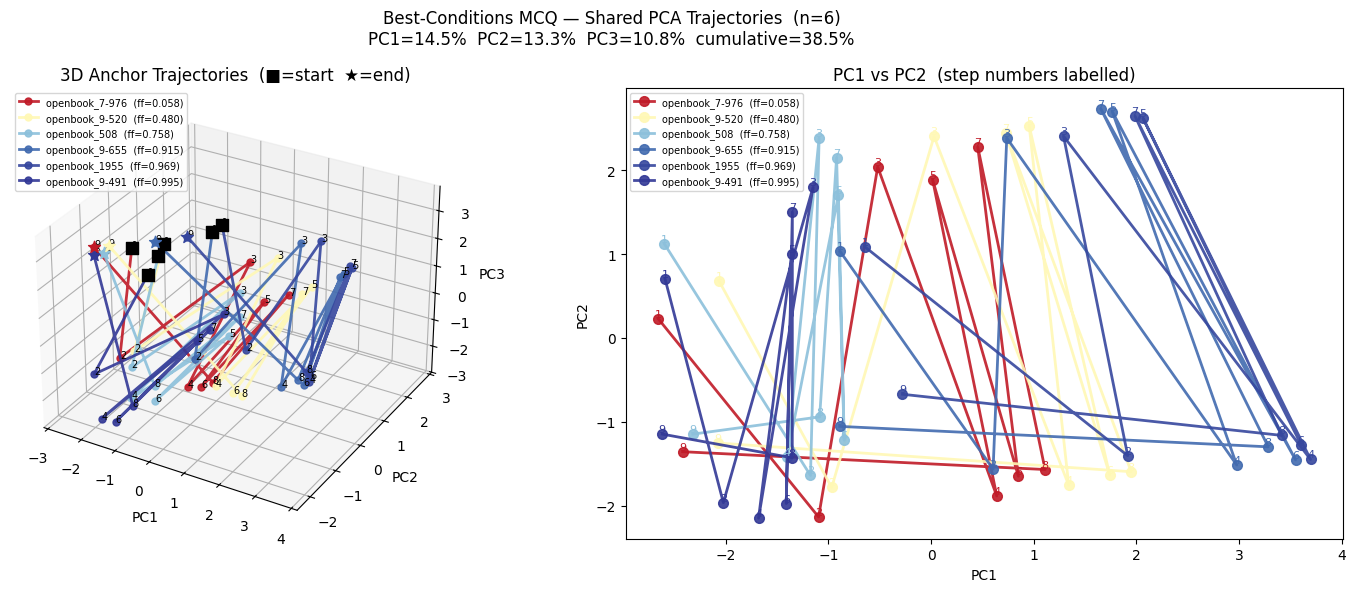

,ff_soft,condition,epoch,arclength,net_displacement,straightness,mean_step_size,step_size_std,mean_curvature,final_pc1,final_pc2,final_pc3,pc1_range,pc2_range
id,,,,,,,,,,,,,,
openbook_7-976,0.0580,sweep_3,1,31.790300,2.0976,0.0660,3.9738,0.4577,0.4568,-2.4185,-1.3546,2.8696,3.7671,4.4072
openbook_9-520,0.4802,sweep_3,1,34.173302,2.4105,0.0705,4.2717,0.5848,0.4639,-2.0787,-1.2505,2.9639,4.0278,4.3057
openbook_508,0.7578,sweep_1,1,28.613501,3.0069,0.1051,3.5767,0.5674,0.4670,-2.3198,-1.1454,2.5191,1.7506,4.0221
openbook_9-655,0.9153,sweep_3,2,35.376301,2.4349,0.0688,4.4220,0.4487,0.4133,-0.8891,-1.0530,3.3514,4.4388,4.2937
openbook_1955,0.9692,sweep_2,2,34.140900,2.0644,0.0605,4.2676,0.3088,0.3516,-0.2779,-0.6704,3.4380,4.3379,4.0897
openbook_9-491,0.9953,sweep_1,1,28.554001,2.8505,0.0998,3.5692,0.6570,0.4414,-2.6177,-1.1450,2.3490,1.4683,3.9407


In [5]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# ── Load best-conditions anchor embeddings ────────────────────────────────────
with open('data/fur_anchor_embeddings.pkl', 'rb') as f:
    records = pickle.load(f)

print(f'Loaded {len(records)} records from data/fur_anchor_embeddings.pkl')
for r in sorted(records, key=lambda x: x['ff_soft']):
    cov = sum(1 for v in r['anchor_embeddings'].values() if v is not None)
    print(f"  {r['question_id']:20s}  ff_soft={r['ff_soft']:.4f}  "
          f"condition={r['condition']}  epoch={r['epoch']}  anchors={cov}/9")

TRAJ_KEYS = [
    'Answer_A', 'Reasoning_A', 'Answer_B', 'Reasoning_B',
    'Answer_C', 'Reasoning_C', 'Answer_D', 'Reasoning_D', 'Final_Answer',
]

# ── Fit a shared PCA across all anchor embeddings ─────────────────────────────
all_vecs = []
for rec in records:
    for k in TRAJ_KEYS:
        v = rec['anchor_embeddings'].get(k)
        if v is not None:
            all_vecs.append(v)

X_all = np.stack(all_vecs).astype(np.float32)
pca = PCA(n_components=3, random_state=42).fit(X_all)
ev = pca.explained_variance_ratio_
print(f'\nShared PCA explained variance:  PC1={ev[0]:.3f}  PC2={ev[1]:.3f}  PC3={ev[2]:.3f}  '
      f'(cumulative={ev[:3].sum():.3f})')

# ── Build per-question trajectory DataFrames ──────────────────────────────────
trajs = []
for rec in records:
    vecs = [rec['anchor_embeddings'].get(k) for k in TRAJ_KEYS]
    valid_keys = [k for k, v in zip(TRAJ_KEYS, vecs) if v is not None]
    valid_vecs = [v for v in vecs if v is not None]
    if len(valid_vecs) < 2:
        print(f"  [SKIP] {rec['question_id']} — too few anchors")
        continue
    proj = pca.transform(np.stack(valid_vecs).astype(np.float32))
    df = pd.DataFrame(proj, columns=['pc1', 'pc2', 'pc3'])
    df['anchor'] = valid_keys
    trajs.append({
        'df':        df,
        'id':        rec['question_id'],
        'ff_soft':   rec['ff_soft'],
        'condition': rec['condition'],
        'epoch':     rec['epoch'],
    })

# Sort low→high ff_soft so the colormap reads intuitively
trajs.sort(key=lambda x: x['ff_soft'])

# ── Color by ff_soft: red (unfaithful) → blue (faithful) ─────────────────────
cmap   = plt.cm.RdYlBu
colors = [cmap(t['ff_soft']) for t in trajs]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))

# 3-D trajectory
ax3d = fig.add_subplot(121, projection='3d')
for t, c in zip(trajs, colors):
    p   = t['df'][['pc1', 'pc2', 'pc3']].values
    lbl = f"{t['id']}  (ff={t['ff_soft']:.3f})"
    ax3d.plot(p[:, 0], p[:, 1], p[:, 2], '-o', color=c, lw=2, markersize=5, label=lbl, alpha=0.9)
    ax3d.scatter(*p[0],  s=80, c='black', marker='s', zorder=5)
    ax3d.scatter(*p[-1], s=80, c=[c],     marker='*', zorder=5)
    for i, row in enumerate(p):
        ax3d.text(row[0], row[1], row[2], str(i + 1), fontsize=7)
ax3d.set_xlabel('PC1'); ax3d.set_ylabel('PC2'); ax3d.set_zlabel('PC3')
ax3d.set_title('3D Anchor Trajectories  (■=start  ★=end)')
ax3d.legend(fontsize=7, loc='upper left')

# PC1 vs PC2
ax2d = fig.add_subplot(122)
for t, c in zip(trajs, colors):
    p   = t['df'][['pc1', 'pc2', 'pc3']].values
    lbl = f"{t['id']}  (ff={t['ff_soft']:.3f})"
    ax2d.plot(p[:, 0], p[:, 1], '-o', color=c, lw=2, markersize=7, label=lbl, alpha=0.9)
    for i, (x, y) in enumerate(zip(p[:, 0], p[:, 1])):
        ax2d.annotate(str(i + 1), (x, y), fontsize=8, ha='center', va='bottom', color=c)
ax2d.set_xlabel('PC1'); ax2d.set_ylabel('PC2')
ax2d.set_title('PC1 vs PC2  (step numbers labelled)')
ax2d.legend(fontsize=7)

plt.suptitle(
    f'Best-Conditions MCQ — Shared PCA Trajectories  (n={len(trajs)})\n'
    f'PC1={ev[0]:.1%}  PC2={ev[1]:.1%}  PC3={ev[2]:.1%}  cumulative={ev[:3].sum():.1%}',
    fontsize=12,
)
plt.tight_layout()
plt.show()

# ── Per-trajectory metric table (uses METRICS from Cell 1) ───────────────────
rows = []
for t in trajs:
    row = {
        'id':        t['id'],
        'ff_soft':   round(t['ff_soft'], 4),
        'condition': t['condition'],
        'epoch':     t['epoch'],
    }
    for name, fn in METRICS:
        row[name] = round(fn(t['df']), 4)
    rows.append(row)

display(pd.DataFrame(rows).set_index('id'))


---
## Hypothesis Tests — Geometry of Faithfulness

The cells below implement the two primary geometry tests the project was built around, plus a null baseline required before interpreting any result.

| Cell | Test |
|------|------|
| Null baseline | Random-pair cosine & displacement distribution from the full anchor-vector pool |
| Test 1 | `reasoning_delta` magnitudes and intra-CoT variance vs `ff_soft` (Spearman) |
| Test 2 | `ff_soft` vs `reasoning_delta_A` (target block) and B/C/D controls |
| Test 3 | Conclusion-probe cosine coupling — skipped if embeddings not present |

> **Note:** n=6.  All Spearman p-values are reported for completeness but are underpowered at this sample size.  The *direction* and *magnitude* of r relative to the null baseline are the meaningful signals.


In [ ]:
import numpy as np
import pickle
from scipy import stats

# Reload records in case this cell is run standalone
with open('data/fur_anchor_embeddings.pkl', 'rb') as _f:
    records = pickle.load(_f)

TRAJ_KEYS = [
    'Answer_A', 'Reasoning_A', 'Answer_B', 'Reasoning_B',
    'Answer_C', 'Reasoning_C', 'Answer_D', 'Reasoning_D', 'Final_Answer',
]

# ── Pool all valid anchor vectors across all questions ────────────────────────
anchor_pool = []
for rec in records:
    for k in TRAJ_KEYS:
        v = rec['anchor_embeddings'].get(k)
        if v is not None:
            anchor_pool.append(v.astype(np.float32))
anchor_pool = np.stack(anchor_pool)   # (N, 4096)
print(f'Anchor pool: {anchor_pool.shape[0]} vectors of dim {anchor_pool.shape[1]}')

rng = np.random.default_rng(42)
N_ITER = 1000

rand_cosines = []
rand_deltas  = []
for _ in range(N_ITER):
    i, j = rng.choice(len(anchor_pool), size=2, replace=False)
    a, b = anchor_pool[i], anchor_pool[j]
    cos = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
    rand_cosines.append(cos)
    rand_deltas.append(float(np.linalg.norm(a - b)))

rand_cosines = np.array(rand_cosines)
rand_deltas  = np.array(rand_deltas)

print('\n── NULL BASELINE (n=1000 random anchor pairs) ──────────────────────────────')
print(f'  Random cosine similarity:   mean={rand_cosines.mean():.4f}  std={rand_cosines.std():.4f}')
print(f'  Random delta magnitude:     mean={rand_deltas.mean():.4f}   std={rand_deltas.std():.4f}')
print(f'  Cosine 1-sigma band:  [{rand_cosines.mean()-rand_cosines.std():.4f},  {rand_cosines.mean()+rand_cosines.std():.4f}]')
print(f'  Delta  1-sigma band:  [{rand_deltas.mean()-rand_deltas.std():.4f},  {rand_deltas.mean()+rand_deltas.std():.4f}]')
print('  → Results within the 1-sigma band should be treated as consistent with chance.')


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

print('══════════════════════════════════════════════════════════════════════════════')
print('TEST 1 — reasoning_delta magnitudes and intra-CoT variance')
print('══════════════════════════════════════════════════════════════════════════════')
print('reasoning_delta[K] = Reasoning_K − Answer_K')
print('||reasoning_delta[K]|| = L2 norm of that displacement vector')
print()

rows = []
for rec in sorted(records, key=lambda x: x['ff_soft']):
    ae = rec['anchor_embeddings']
    qid = rec['question_id']
    ff  = rec['ff_soft']

    deltas = {}
    for letter in ['A', 'B', 'C', 'D']:
        ans_vec  = ae.get(f'Answer_{letter}')
        reas_vec = ae.get(f'Reasoning_{letter}')
        if ans_vec is not None and reas_vec is not None:
            deltas[letter] = float(np.linalg.norm(
                reas_vec.astype(np.float32) - ans_vec.astype(np.float32)
            ))
        else:
            deltas[letter] = None

    valid_deltas = [v for v in deltas.values() if v is not None]
    intra_var = float(np.var(valid_deltas)) if len(valid_deltas) >= 2 else None

    # final_answer_delta = Final_Answer − Reasoning_D
    fa_vec  = ae.get('Final_Answer')
    rd_vec  = ae.get('Reasoning_D')
    if fa_vec is not None and rd_vec is not None:
        final_delta = float(np.linalg.norm(
            fa_vec.astype(np.float32) - rd_vec.astype(np.float32)
        ))
    else:
        final_delta = None

    row = {
        'question_id':    qid,
        'ff_soft':        round(ff, 4),
        'delta_A':        round(deltas['A'], 4) if deltas['A'] is not None else None,
        'delta_B':        round(deltas['B'], 4) if deltas['B'] is not None else None,
        'delta_C':        round(deltas['C'], 4) if deltas['C'] is not None else None,
        'delta_D':        round(deltas['D'], 4) if deltas['D'] is not None else None,
        'intra_variance': round(intra_var, 6)   if intra_var  is not None else None,
        'final_delta':    round(final_delta, 4) if final_delta is not None else None,
    }
    rows.append(row)
    print(f"{qid:20s}  ff={ff:.4f}  "
          f"δA={deltas['A']:.2f}  δB={deltas['B']:.2f}  "
          f"δC={deltas['C']:.2f}  δD={deltas['D']:.2f}  "
          f"intra_var={intra_var:.4f}  final_δ={final_delta:.2f}")

print()
df_t1 = pd.DataFrame(rows).set_index('question_id')
display(df_t1)

# ── Spearman: ff_soft vs intra_variance ──────────────────────────────────────
ff_vals  = [r['ff_soft']        for r in rows if r['intra_variance'] is not None]
iv_vals  = [r['intra_variance'] for r in rows if r['intra_variance'] is not None]
fd_vals  = [r['final_delta']    for r in rows if r['final_delta']    is not None]
ff_fd    = [r['ff_soft']        for r in rows if r['final_delta']    is not None]

r_iv, p_iv = stats.spearmanr(ff_vals, iv_vals)
r_fd, p_fd = stats.spearmanr(ff_fd,   fd_vals)

print('── TEST 1 CORRELATIONS ─────────────────────────────────────────────────────')
print(f'  ff_soft vs intra_variance:  Spearman r = {r_iv:.3f},  p = {p_iv:.3f}  (n={len(ff_vals)})')
direction_iv = 'positive' if r_iv > 0 else 'negative'
null_flag_iv = '  [within null 1-sigma — consistent with chance]' if abs(r_iv) < 0.3 else ''
print(f'    Direction: {direction_iv}{null_flag_iv}')
print(f'    Interpretation: {"higher ff_soft → more variance across blocks" if r_iv > 0 else "higher ff_soft → less variance across blocks"}')
print()
print(f'  ff_soft vs final_delta:     Spearman r = {r_fd:.3f},  p = {p_fd:.3f}  (n={len(ff_fd)})')
direction_fd = 'positive' if r_fd > 0 else 'negative'
print(f'    Direction: {direction_fd}')
print(f'    Interpretation: {"higher ff_soft → larger final-answer displacement" if r_fd > 0 else "higher ff_soft → smaller final-answer displacement"}')
print()
print(f'  Null delta magnitude band: [{rand_deltas.mean()-rand_deltas.std():.2f}, {rand_deltas.mean()+rand_deltas.std():.2f}]')
all_deltas_flat = [r[k] for r in rows for k in ['delta_A','delta_B','delta_C','delta_D'] if r[k] is not None]
within = sum(1 for d in all_deltas_flat if rand_deltas.mean()-rand_deltas.std() < d < rand_deltas.mean()+rand_deltas.std())
print(f'  Observed deltas within null band: {within}/{len(all_deltas_flat)}')


In [ ]:
import numpy as np
from scipy import stats

print('══════════════════════════════════════════════════════════════════════════════')
print('TEST 2 — ff_soft vs reasoning_delta magnitudes (target block A + controls)')
print('══════════════════════════════════════════════════════════════════════════════')
print('All 6 questions had step_idx=0 unlearned → Answer A block is the target step.')
print('ff_soft is the mass shift for that specific step.')
print('Hypothesis: ||reasoning_delta_A|| should correlate most strongly with ff_soft.')
print()

# Collect per-question delta magnitudes
ff_list = []
da_list = []; db_list = []; dc_list = []; dd_list = []

for rec in records:
    ae  = rec['anchor_embeddings']
    ff  = rec['ff_soft']
    row_deltas = {}
    for letter in ['A', 'B', 'C', 'D']:
        a = ae.get(f'Answer_{letter}')
        r = ae.get(f'Reasoning_{letter}')
        if a is not None and r is not None:
            row_deltas[letter] = float(np.linalg.norm(
                r.astype(np.float32) - a.astype(np.float32)
            ))
        else:
            row_deltas[letter] = None

    if all(row_deltas[l] is not None for l in 'ABCD'):
        ff_list.append(ff)
        da_list.append(row_deltas['A'])
        db_list.append(row_deltas['B'])
        dc_list.append(row_deltas['C'])
        dd_list.append(row_deltas['D'])

n = len(ff_list)

r_A, p_A = stats.spearmanr(ff_list, da_list)
r_B, p_B = stats.spearmanr(ff_list, db_list)
r_C, p_C = stats.spearmanr(ff_list, dc_list)
r_D, p_D = stats.spearmanr(ff_list, dd_list)

null_band_lo = rand_deltas.mean() - rand_deltas.std()
null_band_hi = rand_deltas.mean() + rand_deltas.std()

def null_note(vals):
    pct_in = 100 * sum(1 for v in vals if null_band_lo < v < null_band_hi) / len(vals)
    return f' ({pct_in:.0f}% of deltas within null band)'

print(f'TEST 2 — ff_soft vs reasoning_delta_A  (TARGET BLOCK):')
print(f'  Spearman r = {r_A:.3f},  p = {p_A:.3f}  (n={n})')
dir_A = 'positive' if r_A > 0 else 'negative'
print(f'  Direction: {dir_A}{null_note(da_list)}')
print(f'  Interpretation: {"higher ff_soft → larger geometric shift at Answer A reasoning anchor" if r_A > 0 else "higher ff_soft → smaller geometric shift at Answer A reasoning anchor"}')
print()

print('TEST 2 CONTROLS — ff_soft vs reasoning_delta for non-target blocks:')
for lbl, r_val, p_val, vals in [('B', r_B, p_B, db_list),
                                   ('C', r_C, p_C, dc_list),
                                   ('D', r_D, p_D, dd_list)]:
    dir_lbl = 'pos' if r_val > 0 else 'neg'
    print(f'  ff_soft vs reasoning_delta_{lbl}:  r = {r_val:.3f},  p = {p_val:.3f}  ({dir_lbl}){null_note(vals)}')

print()
r_vals = {'A': r_A, 'B': r_B, 'C': r_C, 'D': r_D}
strongest = max(r_vals, key=lambda k: abs(r_vals[k]))
if strongest == 'A':
    print('  ✓ Answer A shows the strongest |r| — consistent with hypothesis.')
else:
    print(f'  ✗ Answer {strongest} shows stronger |r| than A ({abs(r_vals[strongest]):.3f} vs {abs(r_A):.3f}).')
    print(f'    This is an interesting negative result: the FUR-identified step (A) does')
    print(f'    not show the strongest geometric-faithfulness coupling at this sample size.')
print()
print('  Null delta magnitude band (1-sigma): '
      f'[{null_band_lo:.2f}, {null_band_hi:.2f}]')


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

print('══════════════════════════════════════════════════════════════════════════════')
print('TEST 3 — Conclusion-probe cosine coupling (within-block geometric alignment)')
print('══════════════════════════════════════════════════════════════════════════════')

# Check what conclusion keys are present
first = records[0]
print(f'\nFirst record top-level keys: {list(first.keys())}')
print(f'anchor_embeddings keys:      {list(first["anchor_embeddings"].keys())}')
ce_keys = list(first.get('conclusion_embeddings', {}).keys())
print(f'conclusion_embeddings keys:  {ce_keys}')

# Count coverage
coverage = {}
for rec in records:
    ce = rec.get('conclusion_embeddings', {})
    cov = sum(1 for v in ce.values() if v is not None)
    coverage[rec['question_id']] = cov
print(f'\nConclusion embedding coverage per question:')
for qid, n in coverage.items():
    print(f'  {qid:20s}: {n}/4 blocks')

usable = [rec for rec in records
          if any(v is not None for v in rec.get('conclusion_embeddings', {}).values())]

if not usable:
    print()
    print('NOTE: conclusion_embeddings are all None across all records.')
    print('Test 3 requires a separate extraction pass to populate Conclusion token')
    print('embeddings. Skipping.')
else:
    print(f'\n{len(usable)} record(s) have at least one Conclusion embedding — proceeding.')
    print()

    def cosine(a, b):
        a, b = a.astype(np.float32), b.astype(np.float32)
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

    rows = []
    for rec in sorted(usable, key=lambda x: x['ff_soft']):
        ae = rec['anchor_embeddings']
        ce = rec['conclusion_embeddings']
        row = {'question_id': rec['question_id'], 'ff_soft': round(rec['ff_soft'], 4)}
        for letter in ['A', 'B', 'C', 'D']:
            reas = ae.get(f'Reasoning_{letter}')
            conc = ce.get(letter)
            if reas is not None and conc is not None:
                row[f'cos_{letter}'] = round(cosine(reas, conc), 4)
            else:
                row[f'cos_{letter}'] = None
        row['mean_cos'] = round(
            np.mean([v for k, v in row.items() if k.startswith('cos_') and v is not None]),
            4
        )
        rows.append(row)

    df_t3 = pd.DataFrame(rows).set_index('question_id')
    display(df_t3)

    # Mean cosine per block across available questions
    print('\nMean cosine per block (across questions with data):')
    for letter in ['A', 'B', 'C', 'D']:
        vals = [r[f'cos_{letter}'] for r in rows if r.get(f'cos_{letter}') is not None]
        if vals:
            print(f'  Block {letter}: mean cosine = {np.mean(vals):.4f}  (n={len(vals)})')
        else:
            print(f'  Block {letter}: no data')

    # Spearman: ff_soft vs cos_A
    paired = [(r['ff_soft'], r['cos_A']) for r in rows if r.get('cos_A') is not None]
    if len(paired) >= 3:
        ff_cos, cos_A = zip(*paired)
        r_cos, p_cos = stats.spearmanr(ff_cos, cos_A)
        print(f'\nSpearman ff_soft vs cos_A:  r = {r_cos:.3f},  p = {p_cos:.3f}  (n={len(paired)})')
    else:
        print(f'\nOnly {len(paired)} paired observations — Spearman not computed for cos_A.')

    # Null baseline reference
    print(f'\nNull cosine band (1-sigma): [{rand_cosines.mean()-rand_cosines.std():.4f}, {rand_cosines.mean()+rand_cosines.std():.4f}]')
    all_cos = [r[f'cos_{l}'] for r in rows for l in 'ABCD' if r.get(f'cos_{l}') is not None]
    if all_cos:
        within = sum(1 for c in all_cos
                     if rand_cosines.mean()-rand_cosines.std() < c < rand_cosines.mean()+rand_cosines.std())
        print(f'Observed cosines within null band: {within}/{len(all_cos)}')
